<a href="https://colab.research.google.com/github/Rasheedovsky/Projects/blob/main/Show_case_finmarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fredapi
!pip install yfinance
!pip install yahoo_fin

In [ ]:
from fredapi import Fred as fd
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from datetime import date
from datetime import datetime as dt
from yahoo_fin import options
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
fred = fd(api_key='PUT YOUR KEY HERE')

# Scenario 1: Credit cards

In [ ]:
# Let's get credit card interest rate and FED interest rate over the same period
credit_card_rate = fred.get_series('TERMCBCCALLNS', observation_start='1994-01-01', observation_end='2024-05-01')
fed_rate = fred.get_series('FEDFUNDS', observation_start='1994-01-01', observation_end='2024-05-01')

Text(0.5, 1.0, 'Commercial banks Credit card interest rate distribution')

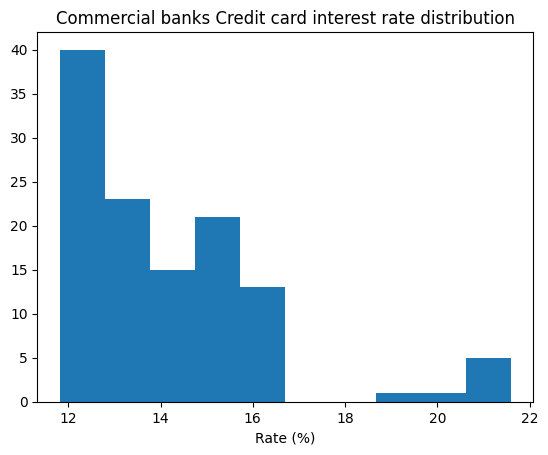

In [ ]:
plt.hist(credit_card_rate)
plt.xlabel('Rate (%)')
plt.title('Commercial banks Credit card interest rate distribution')

> Credit card interest rate is mostly between 12 - 18% annually. In some rare cases, it can reach as high as 22% per year

In [ ]:
# Fill NaN value in credit_card_rate by the previous non-null value of the first month in the same quarter
credit_card_rate.ffill(inplace=True)

# Merge credit card and FED interest rate to compare
df = pd.DataFrame({'CC_Rate': credit_card_rate, 'FED_Rate': fed_rate})

Text(0.5, 1.0, 'Commercial banks Credit card and FED interest rates')

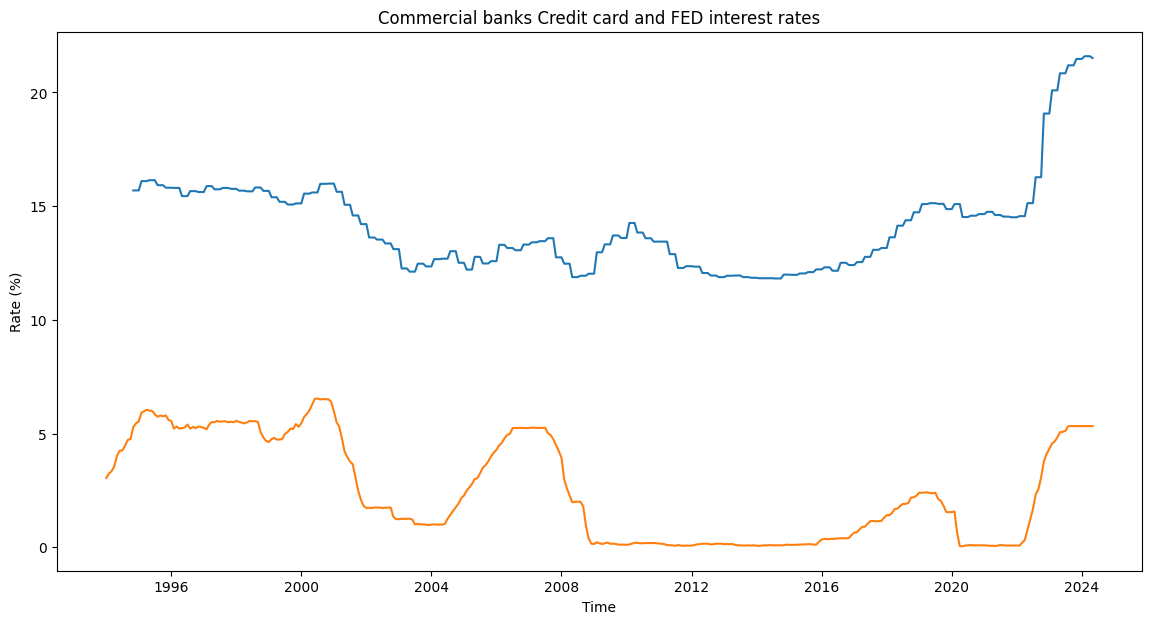

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(credit_card_rate.index, credit_card_rate.values)
ax.plot(fed_rate.index, fed_rate.values)

ax.set_xlabel('Time')
ax.set_ylabel('Rate (%)')
ax.set_title('Commercial banks Credit card and FED interest rates')

In [ ]:
# Calculate correlation between credit card and FED interest rate
df['CC_Rate'].corr(df['FED_Rate'], method="spearman")

0.6682268347883498


> Credit card interest rate and FED interest rate have quite high correlation coefficient and vary in a positive relationship. The reason is when FED's rate changes, credit card interest rate must be adjusted accordingly so that it is profitable for the banks and also attractive for borrower

# Scenario 2: Mortgages

In [ ]:
# Let's get 15-Year Fixed Rate Mortgage Average in the United States data
mortgages_rate = fred.get_series('MORTGAGE15US')

Text(0.5, 1.0, 'US Mortgages Rate Over Time')

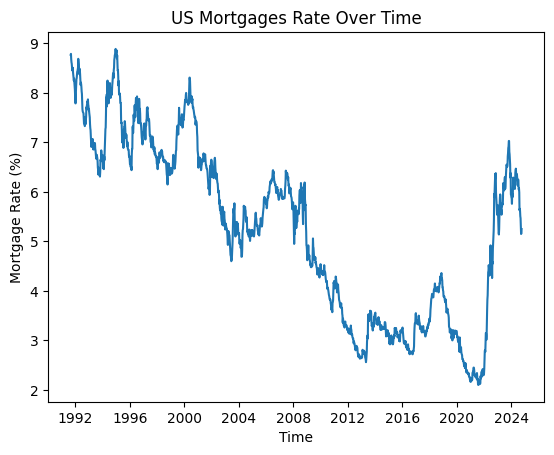

In [ ]:
plt.plot(mortgages_rate.index, mortgages_rate.values)
plt.xlabel('Time')
plt.ylabel('Mortgage Rate (%)')
plt.title('US Mortgages Rate Over Time')

Text(0.5, 1.0, 'US Mortgages Delinquency rate VS time')

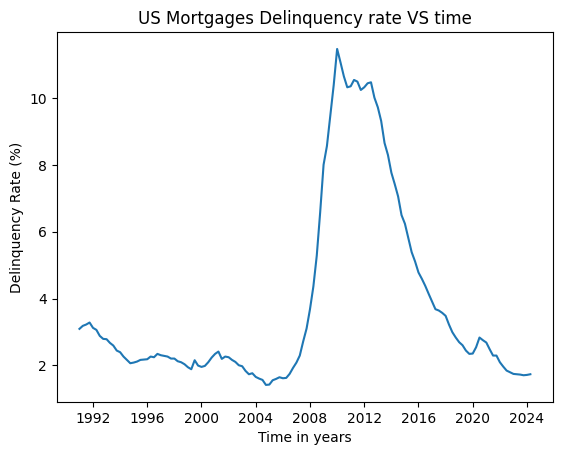

In [ ]:
mortgages_delinquency_rate = fred.get_series('DRSFRMACBS')
plt.plot(mortgages_delinquency_rate.index, mortgages_delinquency_rate.values)
plt.xlabel('Time in years')
plt.ylabel('Delinquency Rate (%)')
plt.title('US Mortgages Delinquency rate VS time')

In [ ]:
# Calculate the correlation between mortgage rate and delinquency rate
resampled_mortgages_rate = mortgages_rate.resample('Q').mean()
resampled_mortgages_rate.reset_index(drop=True).corr(mortgages_delinquency_rate[1:].reset_index(drop=True), method="spearman")

<ipython-input-229-dac920c17198>:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  resampled_mortgages_rate = mortgages_rate.resample('Q').mean()


-0.48753967838563317


> Mortgage rate and delinquency rate have no correlation. So it is safe to assume that mortgage rate has no effect on defaults or delinquency. The only noticeable thing about delinquency rate is a peak from 2008 to 2012, after the Great Financial Crisis

# Scenario 3: Money at a fixed rate for a business for a construction loan.


In [ ]:
# Let's get Business loan delinquency rate and FED interest rate over the same period
delinquency_loan_rate = fred.get_series('DRBLACBS', observation_start='1996-01-01', observation_end='2024-05-01')
fed_rate = fred.get_series('FEDFUNDS', observation_start='1996-01-01', observation_end='2024-05-01')

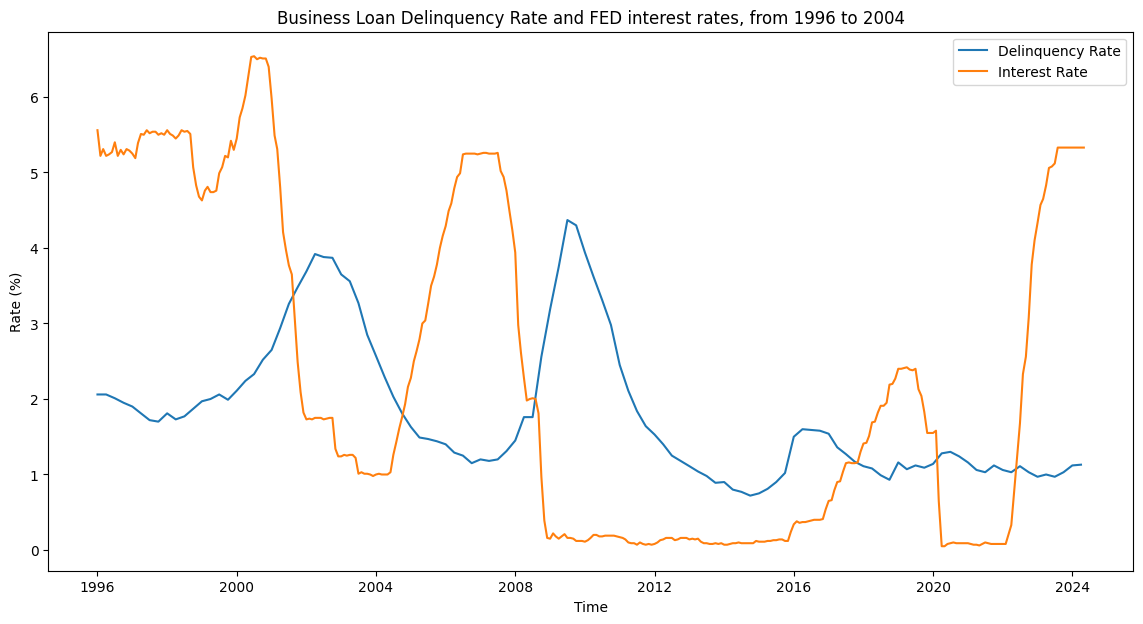

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(delinquency_loan_rate.index, delinquency_loan_rate.values, label="Delinquency Rate")
ax.plot(fed_rate.index, fed_rate.values, label="Interest Rate")
ax.set_xlabel('Time')
ax.set_ylabel('Rate (%)')
ax.set_title('Business Loan Delinquency Rate and FED interest rates, from 1996 to 2004')
ax.legend()


> From 2000 to 2012, we can observe a relationship between business loan delinquency and central bank interest rate. Delinquency rate peaks lag with interest rate peaks by a period of about 2 years. However, since 2020, we can see a surge in interest rate but the delinquency rate shows little changes. So we cannot conclude a clear causal or correllation between interest rate and business loan delinquency


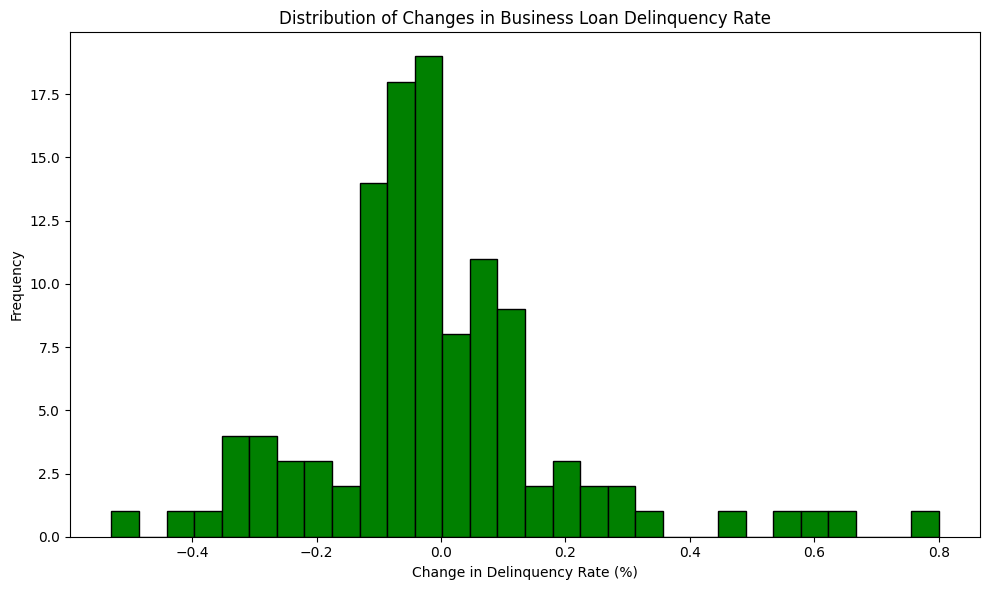

In [ ]:
# Distribution of delinquency rate changes

import matplotlib.pyplot as plt

# Distribution of delinquency rate changes
delinquency_rate_diff = delinquency_loan_rate.diff().dropna()

# Create a figure and axis for the histogram
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histogram
ax.hist(delinquency_rate_diff, bins=30, color='green', edgecolor='black')
ax.set_xlabel('Change in Delinquency Rate (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Changes in Business Loan Delinquency Rate')

plt.tight_layout()
plt.show()


> There is a slight skewness to the right indicating that the distribution of Changes in Business Loan Delinquency Rate is slightly positively skewed. Most data points are around the mean.


#Scenario 4: AAPL equity



In [ ]:
'''Use Python to graph series, distributions, 2-way relationships, and any other meaningful
visuals that show insight into the data. Your group will decide both what to graph, and
write the code to create them. Each visual must include 1 sentence that must explicitly
describe the insight.
'''
vix = yf.download("^VIX", period="5y", interval="1d") # downloading the VIX data

aapl = yf.download('aapl', period="5y", interval="1d") # Downloading the equity

spy = yf.download('spy', period="5y", interval="1d") #Downloading the SP500 as a representative of the market



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
aapl['ret']=aapl['Close'].pct_change()*100
vix['ret']=vix['Close'].pct_change()*100
spy['ret']=spy['Close'].pct_change()*100
spy.dropna(inplace=True)
vix.dropna(inplace=True)
aapl.dropna(inplace=True)

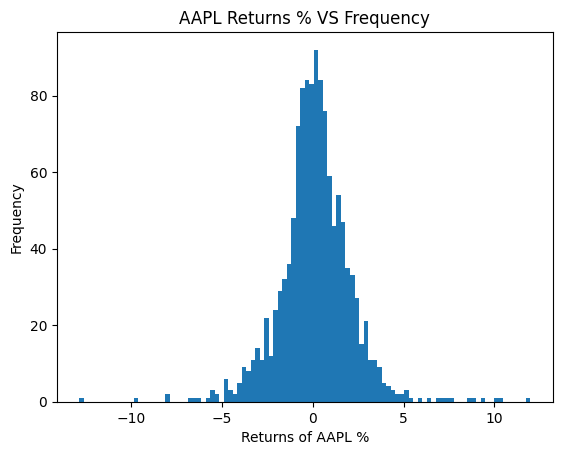

In [ ]:
plt.hist(aapl['ret'],bins=100)
plt.xlabel('Returns of AAPL %')
plt.ylabel('Frequency')
plt.title('AAPL Returns % VS Frequency')
plt.show()

#We see there is a slgiht skewness to the right but all we can say about the return distribution is if it is Gaussian or not within a specific window of confidence so we start by using Kolmogrov-Smirnov Normality test.

In [ ]:
ks_statistic, p_value = stats.kstest(aapl['ret'], 'norm', args=(aapl['ret'].mean(), aapl['ret'].std()))

print(f"K-S Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

K-S Statistic: 0.07077865622052545
P-value: 6.330411471598906e-06


#We see that the data are not normally distibuted which is expected as return follow a power-law and have more inclination to go up due to inflation

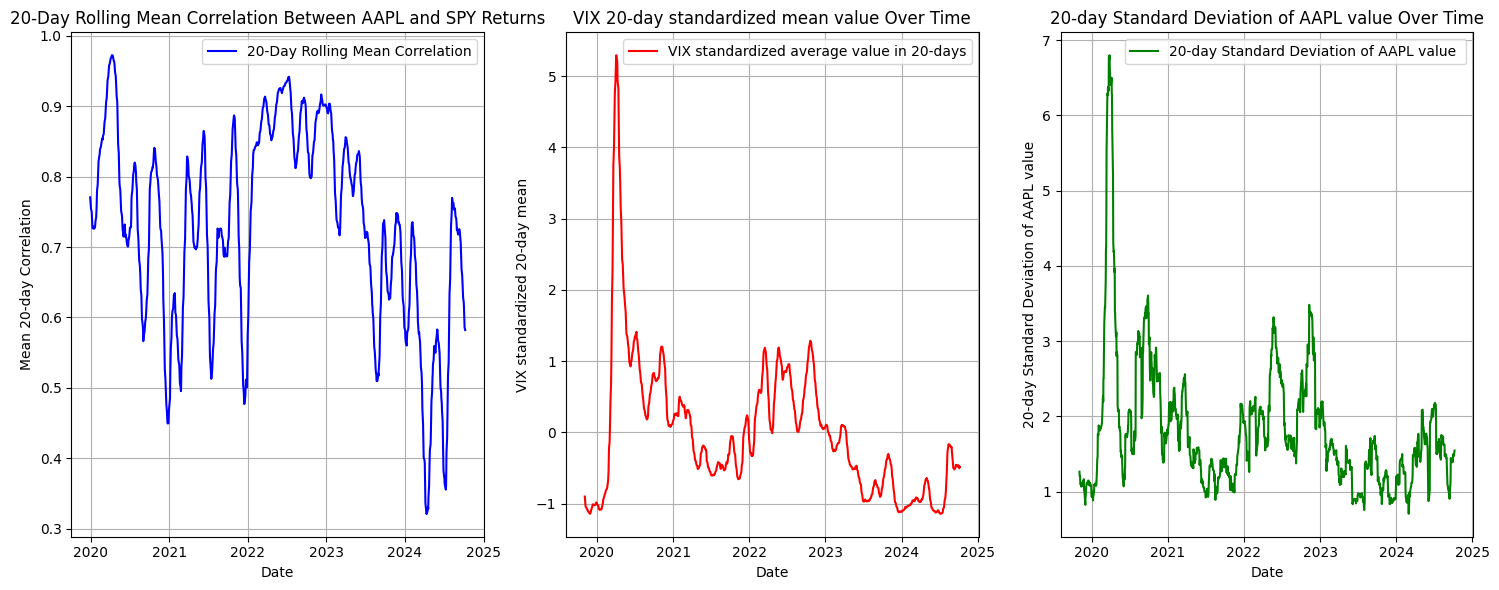

In [ ]:
spy['sret']=(spy['ret']-spy['ret'].mean())/spy['ret'].std()
aapl['sret']=(aapl['ret']-aapl['ret'].mean())/aapl['ret'].std() #standardizing the returns for both return series whether it is spy or aapl
vix['mean_vol']=vix['Close'].rolling(window=20).mean()

vix['smean_vol']=(vix['mean_vol']-vix['mean_vol'].mean())/vix['mean_vol'].std()

aapl['stdev']=aapl['ret'].rolling(20).std()# monthly volatility (20 trading days)
aapl.dropna(inplace=True)

aligned_data = pd.DataFrame({'aapl_sret': aapl['sret'], 'spy_sret': spy['sret']}).dropna() #putting them in the same data frame



aligned_data['corr'] = aligned_data['aapl_sret'].rolling(window=20).corr(aligned_data['spy_sret']).rolling(window=20).mean()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

# Plot 1: Rolling 20-day mean correlation between AAPL and SPY
axes[0].plot(aligned_data.index, aligned_data['corr'], label='20-Day Rolling Mean Correlation', color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Mean 20-day Correlation')
axes[0].set_title('20-Day Rolling Mean Correlation Between AAPL and SPY Returns')
axes[0].grid(True)
axes[0].legend()

# Plot 2: VIX standardized mean value over time
axes[1].plot(vix.index, vix['smean_vol'], label='VIX standardized average value in 20-days', color='red')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('VIX standardized 20-day mean')
axes[1].set_title('VIX 20-day standardized mean value Over Time')
axes[1].grid(True)
axes[1].legend()


axes[2].plot(aapl.index, aapl['stdev'], label='20-day Standard Deviation of AAPL value ', color='green')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('20-day Standard Deviation of AAPL value')
axes[2].set_title('20-day Standard Deviation of AAPL value Over Time')
axes[2].grid(True)
axes[2].legend()
# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#On the upper left, we see that the correlation between the market returns and apple stock returns are volatile, on the right we also notice that this correlation is also going up when the VIX goes up (Middle graph), at least within the averaging period of 20-days or once month of trading. Finally, we see that the moving standard deviation of apple goes up as well once the correlation goes up and when vix goes up. indication some sort of correlation between them (Right most plot).

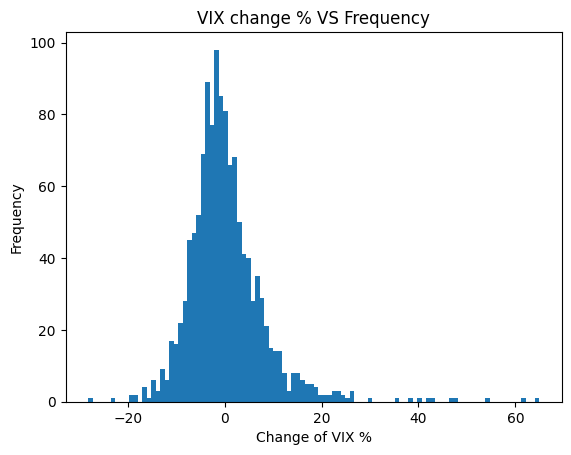

In [ ]:
plt.hist(vix['ret'],bins=100)
plt.xlabel('Change of VIX %')
plt.ylabel('Frequency')
plt.title('VIX change % VS Frequency')
plt.show()

#It seems that the VIX does change more dramatically to the right side (more upward extremes than downward) we do not claim anything on the distribution.

In [ ]:
data = pd.DataFrame({'aapl_ret': aapl['ret'], 'vix_ret': vix['ret']}).dropna()
data.describe()

,aapl_ret,vix_ret
count,1239.000000,1239.000000
mean,0.120721,0.349879
std,2.005330,8.116731
min,-12.864696,-28.156600
25%,-0.837620,-4.178955
50%,0.117240,-0.746579
75%,1.214803,3.479453
max,11.980827,64.899533


Intercept: 0.17661909088448627
Coefficient: -0.13035807224824553
Mean Squared Error: 2.814234656684706
R-squared: 0.30618381175176945


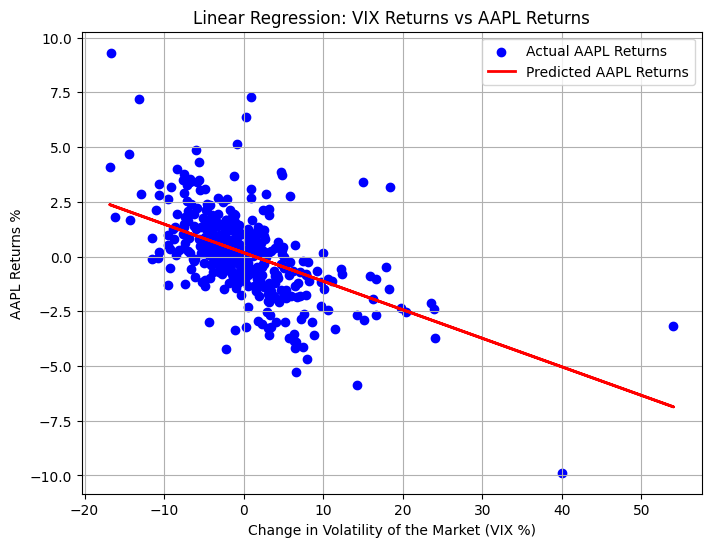

In [ ]:
X = data[['vix_ret']]
y = data['aapl_ret']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

model=LinearRegression()
model.fit(X_train,y_train)
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")
y_pred = model.predict(X_test)

# Calculate mean squared error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual AAPL Returns')
plt.plot(X_test, y_pred, color='red', label='Predicted AAPL Returns' , linewidth=2)
plt.xlabel('Change in Volatility of the Market (VIX %)')
plt.ylabel('AAPL Returns %')
plt.title('Linear Regression: VIX Returns vs AAPL Returns')
plt.legend()
plt.grid(True)
plt.show()

#Although linear regression requires no outliers as an assumption, but clearly there is a negative relationship between market volatility and negative returns of stocks (In this case AAPL). In this simple model we find that market volatility explains 19% of stock returns in this model. which significant considering that there are so many other factors that get into variability of returns from Macro news to micro news. We also use Speaman correltion to catch non-linear correlation and it shows a good negative correlation between the stock and volatility

In [ ]:
data['vix_ret'].corr(data['aapl_ret'],method='spearman') #Spearman correlation

-0.5527336415605801

In [ ]:
data['vix_ret'].corr(data['aapl_ret'],method='kendall') #kenadall correlation

-0.39275527575291164

In [ ]:
data['vix_ret'].corr(data['aapl_ret']) # Pearson correlation

-0.5507517436098013

#Due to high concentration of volatility changes around 0 we see a cluster, however, there is so sort of a relationship between high VIX changes and lower returns. We plot a linear regression line between them and show that VIX can explain

Intercept: 0.07884275559708023
Coefficient: -0.00025212003239841256
Mean Squared Error: 3.8879015569563986
R-squared: -0.005248804549517816


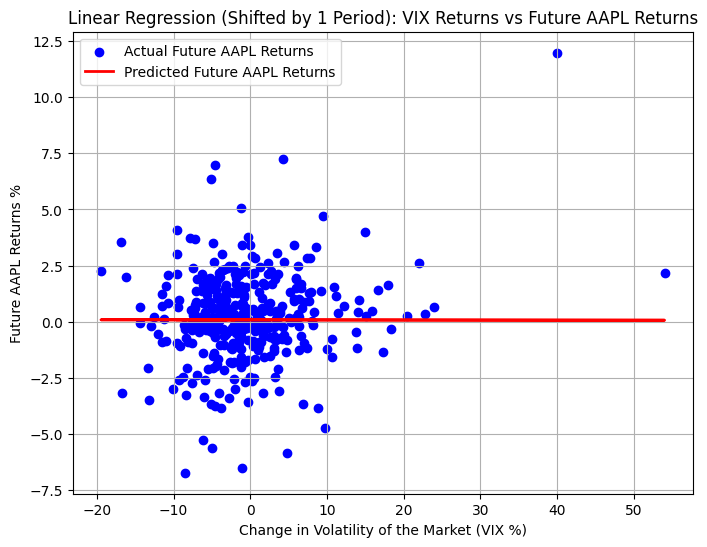

In [ ]:
#Finally we repeat the analysis but with a shifted period of one day to see if there is some sort of causal relationship
shift_period = 1  # We can change this to explore different shift periods
data['aapl_future_ret'] = data['aapl_ret'].shift(-shift_period)  # Future aapl returns
shifted_data = data.dropna()

# Define independent (X) and dependent (y) variables
X = shifted_data[['vix_ret']]  # VIX returns as independent variable
y = shifted_data['aapl_future_ret']  # Future AAPL returns as dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Plot actual vs predicted future AAPL returns
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Future AAPL Returns')
plt.plot(X_test, y_pred, color='red', label='Predicted Future AAPL Returns', linewidth=2)
plt.xlabel('Change in Volatility of the Market (VIX %)')  # VIX returns
plt.ylabel('Future AAPL Returns %')  # Future AAPL returns
plt.title(f'Linear Regression (Shifted by {shift_period} Period): VIX Returns vs Future AAPL Returns')
plt.legend()
plt.grid(True)
plt.show()

#We see that the relationship between volatility index and returns are not exactly causal, at least in the linear domain, which makes more since. The most likely reasin for the correlation between them is to be a third factor (Macro economic or geopolotical news) that causes both to correlate so much.

In [ ]:
#Let us check a different way to see what extreme volatility does to liquidity

In [ ]:
#redoing everything
# We get the stock data directly from yahoo finance as it is easy and provides enough to analyze.
df=yf.download('AAPL',period='5y', interval='1d')# we will use AAPL
df.isna().sum() #1-Get data [check]
#Clean[check]

[*********************100%***********************]  1 of 1 completed


,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.describe() #initial view[check]

,Open,High,Low,Close,Adj Close,Volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,145.864599,147.494285,144.340455,145.995154,144.298300,9.326025e+07
std,41.405198,41.654201,41.120097,41.392027,41.892767,5.266957e+07
min,56.455002,56.947498,53.152500,56.092499,54.284836,2.085230e+07
25%,123.960003,125.294998,122.250000,124.325001,121.564133,5.882020e+07
50%,148.949997,150.399994,147.509995,149.100006,147.018127,7.926520e+07
75%,174.084999,175.995003,172.575005,174.584999,172.870277,1.102086e+08
max,236.479996,237.229996,233.089996,234.820007,234.548523,4.265100e+08


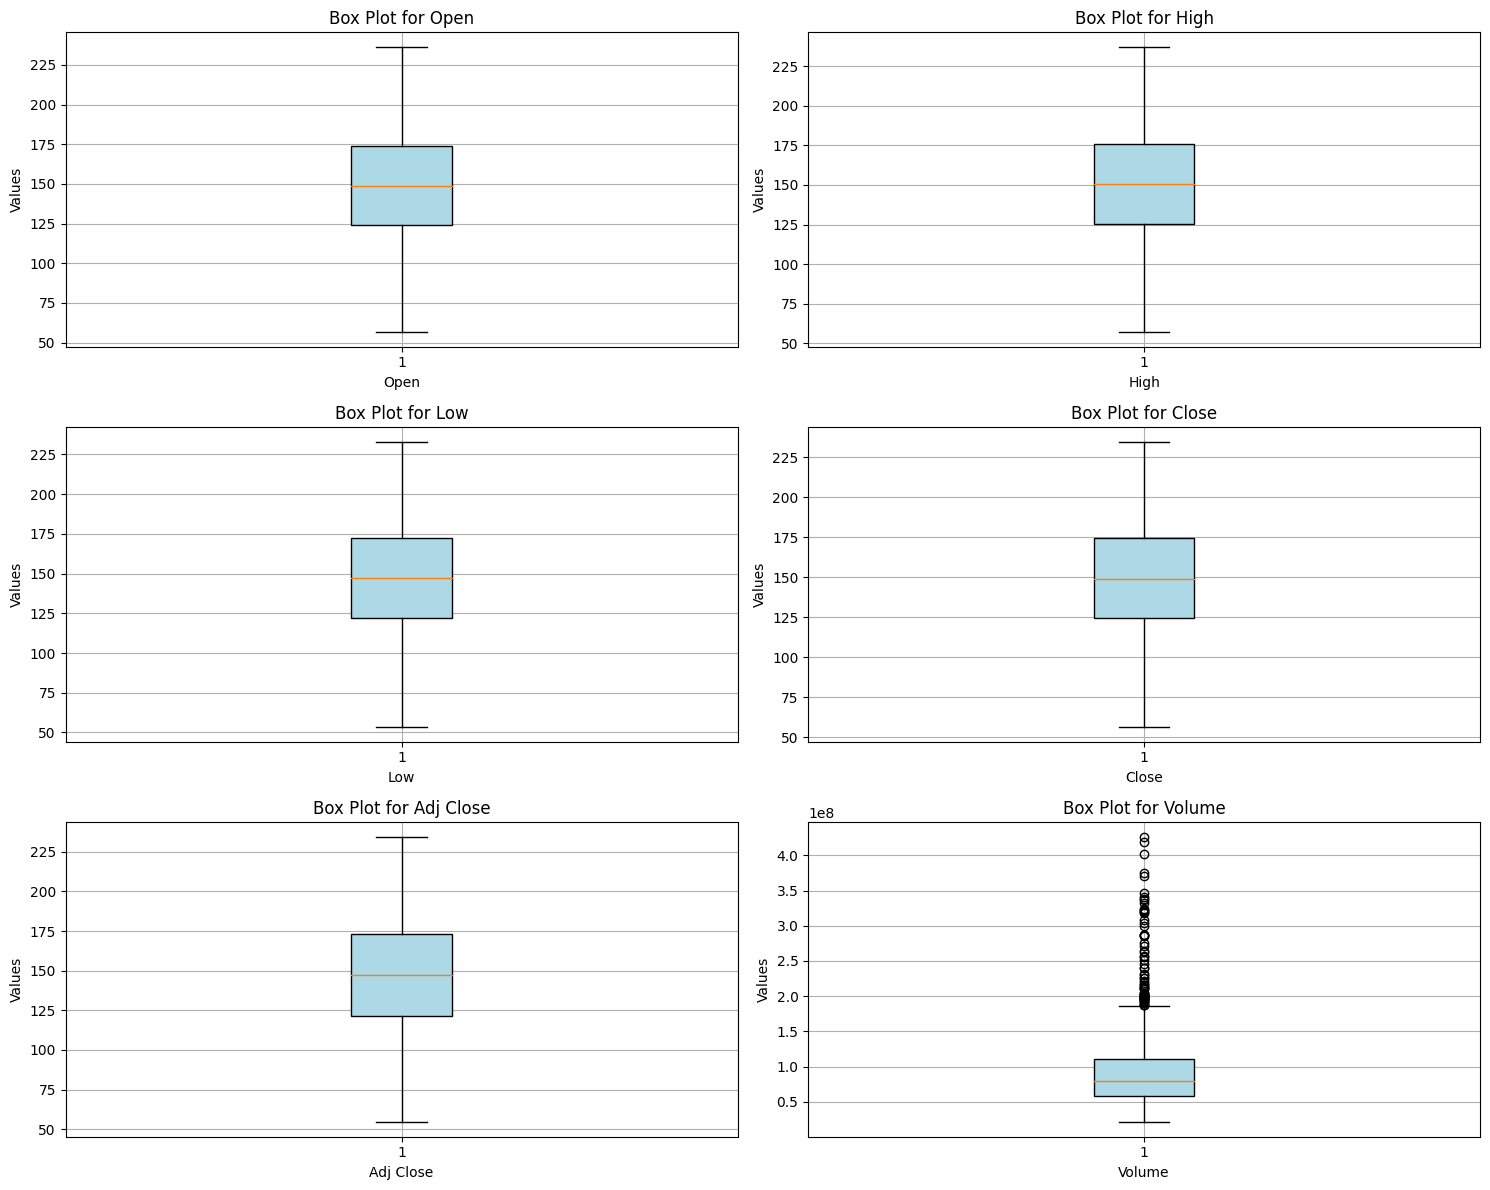

In [ ]:
#initial visual check [Check]
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Values')
    axes[i].grid(True)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We see that the volume data has a lot of extreme values. We will analyze True range and the volume size in the project. On the other hand the price data does not show extremes in the daily data in the box plot graph case, we can do an alaysis oveer the returns.

{'whiskers': [<matplotlib.lines.Line2D at 0x7c147366e4a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c147366d000>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c1473527df0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c147366ce80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c147366f3a0>],
 'means': []}

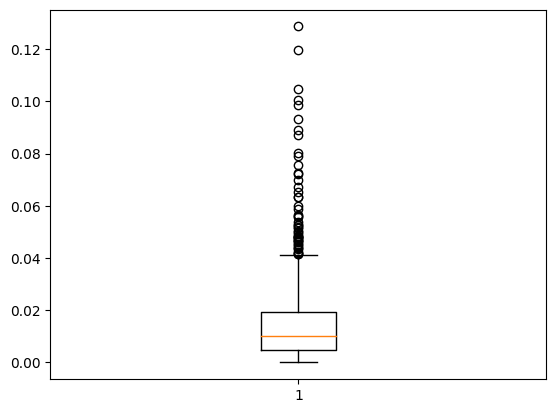

In [ ]:
df['ret']=df['Adj Close'].pct_change()
df['ret']=df['ret'].fillna(0) #data manipulation to get more features and cleaning [Check]
plt.boxplot(df['ret'].abs()) #checking the new feature [check]

We see that the returns also show a lot of extremes when taking the absolute value (even without the absolute value) which is proof of fat tails to a degree.

In [ ]:
#True range =tr, remember we can improve this by normalization
df['tr'] = (df[['High', 'Low', 'Adj Close']]
                    .apply(lambda x: max(x['High'] - x['Low'],
                    abs(x['High']- x['Adj Close']),
                    abs(x['Low'] - x['Adj Close'])), axis=1))


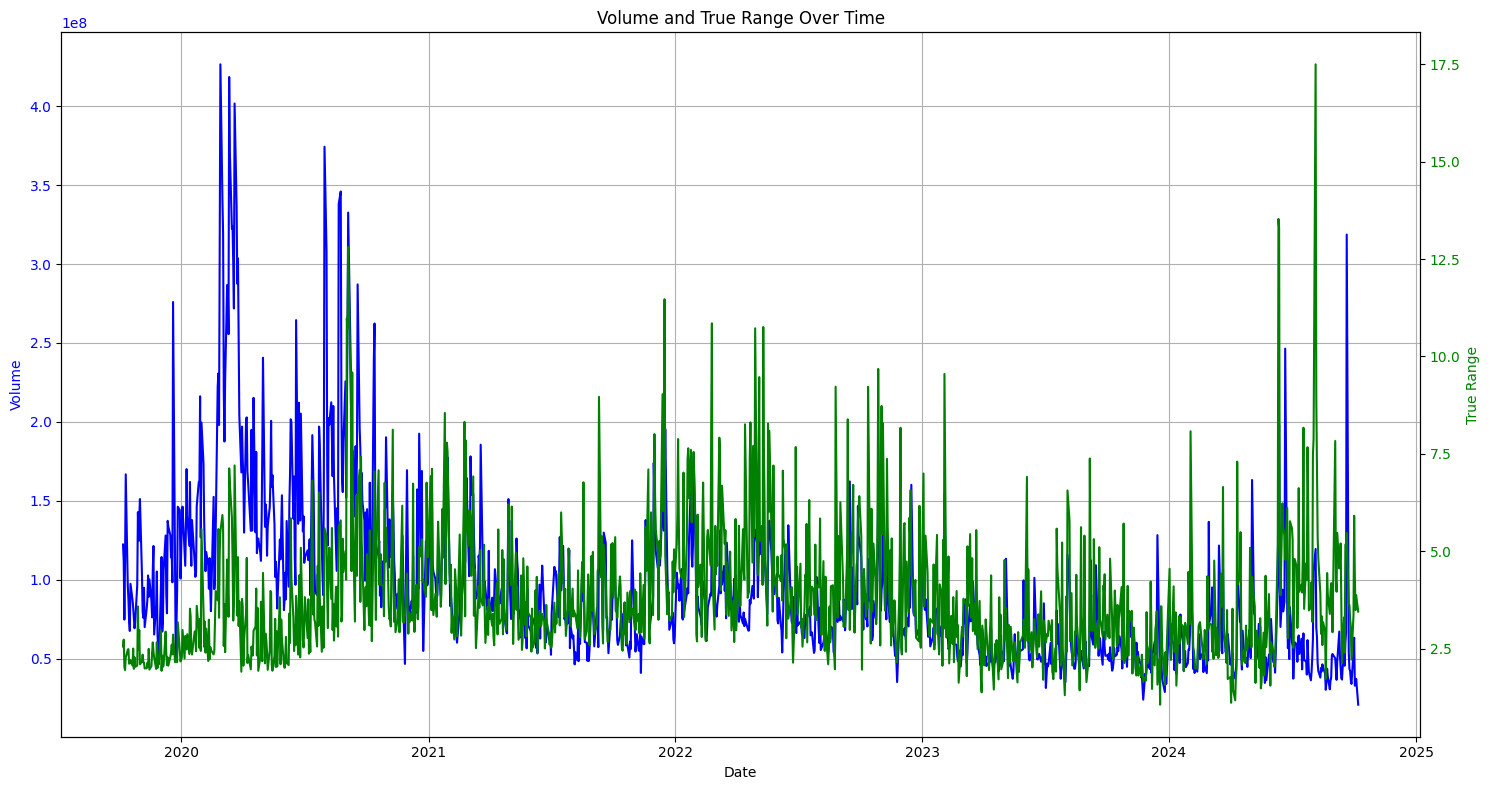

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(df.index, df['Volume'], color='blue', label='Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(df.index, df['tr'], color='green', label='True Range')
ax2.set_ylabel('True Range', color='green')
ax2.tick_params(axis='y', labelcolor='green')
plt.title('Volume and True Range Over Time')
ax1.grid(True)
plt.tight_layout()
plt.show()

we can see a graph of the volume and true range (a measure of volatility over time. just from the graph we can guess some sort of correlation. Maybe if we filter data into extremes and regular retrurns (Exclude rows with the top 1% percent of the absolute returns)

In [ ]:
#correlation and auto_correlation, pearson is automatic
df['Volume'].corr(df['tr'])

0.3610533572985431

<Figure size 1000x600 with 0 Axes>

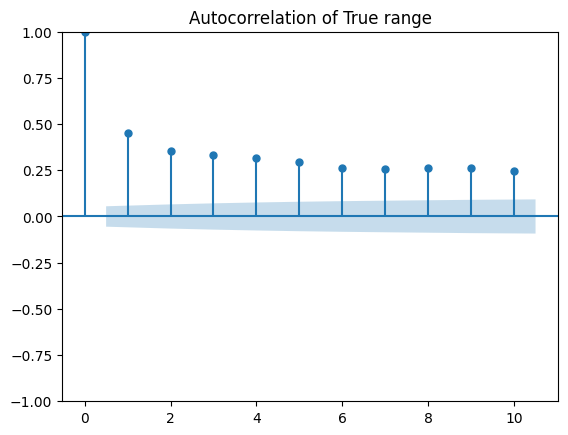

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 6))
plot_acf(df['tr'].dropna(), lags=10)  # Adjust lags if needed but it seems stable
ax.set_xlabel('Lags')
ax.set_ylabel('Correlation')
plt.title('Autocorrelation of True range')
plt.show()

we see that the true range has a natural autocorrelation between0.50 and 0.25 about immediately after the first value. Hence we would assume it is not really important. this continues with longer lags indicating similar change in general.

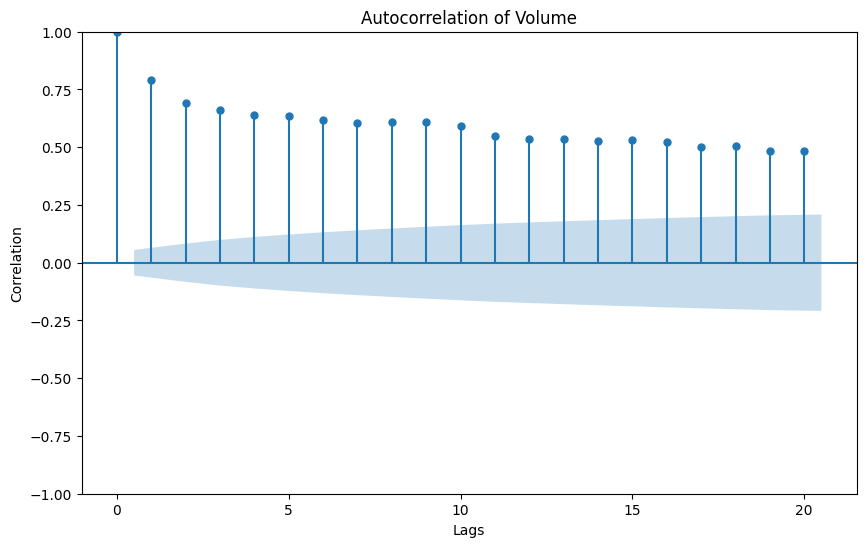

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(df['Volume'], lags=20, ax=ax)  # Adjust lags as needed
ax.set_xlabel('Lags')
ax.set_ylabel('Correlation')
ax.set_title('Autocorrelation of Volume')
plt.show()

Generally the volume is better autocorrelated than volatility in the next day, we see that yesterday's volume is highly corrrelated(above 50%) to today's volume at least in a 20-days cycle.

In [ ]:
df['abs_ret']=df['ret'].abs() #segmentation by the return data the "new" feature

topdf=df[df['abs_ret']>=df['abs_ret'].quantile(0.99)]
bottomdf=df[df['abs_ret']<df['abs_ret'].quantile(0.99)]

In [ ]:
#repeat the analysis above but after seperation
topdf['Volume'].corr(topdf['tr'])
#We see that in extreme values, negative correlation between true range and Volume
#This proves our previous work that extremes, is associated with drying up liquidity

-0.36730475355303255

In [ ]:
bottomdf['Volume'].corr(bottomdf['tr'])
#while there is a similar low correlation between tr and volume in the lower return range

0.34581301511987583

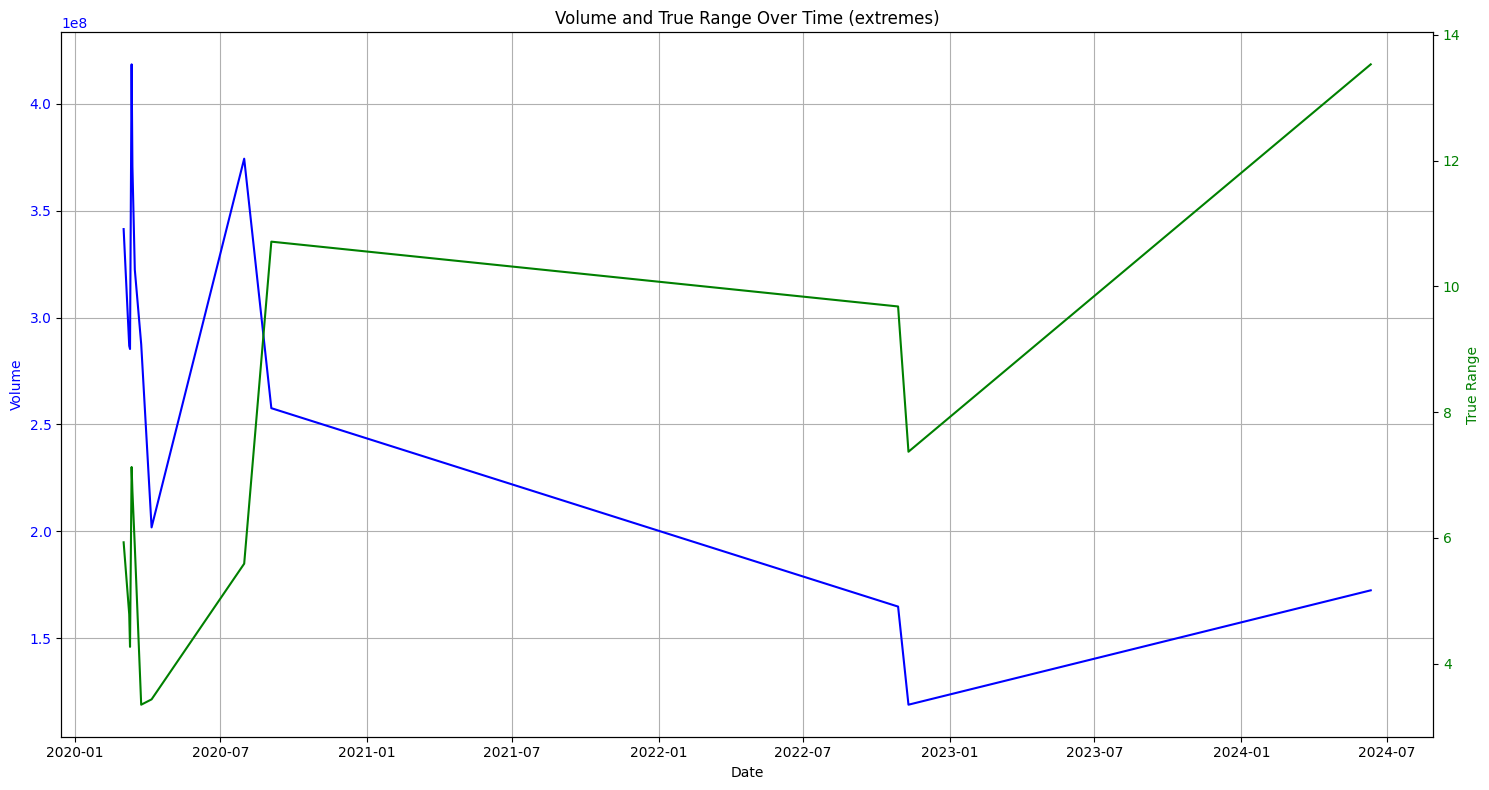

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(topdf.index, topdf['Volume'], color='blue', label='Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(topdf.index, topdf['tr'], color='green', label='True Range')
ax2.set_ylabel('True Range', color='green')
ax2.tick_params(axis='y', labelcolor='green')
plt.title('Volume and True Range Over Time (extremes)')
ax1.grid(True)
plt.tight_layout()
plt.show()

While they may look the same, but they do diverge from eachother. Hence, more ways to say (crashes deplete volatility)

#Scenario 5: Bonds

In [ ]:
# Let's get US Government 10-Year Bond Yields
bond_rate = fred.get_series('IRLTLT01USM156N')

Text(0.5, 1.0, 'US Government 10-Year Bond Yields')

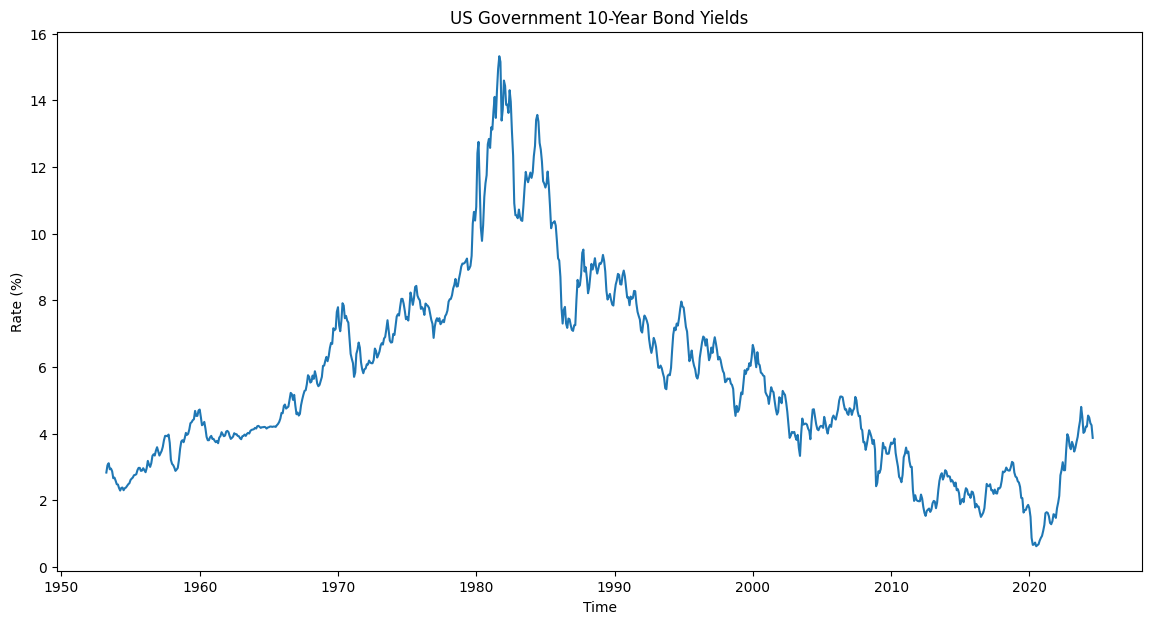

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(bond_rate.index, bond_rate.values)
ax.set_xlabel('Time')
ax.set_ylabel('Rate (%)')
ax.set_title('US Government 10-Year Bond Yields')



> Ignore low time frame movement, we can see bond yield rising from the 1950s and peaked in 1981, then gradually decrease until 2020, which then rise again until now. Let's look at US CPI and see if inflation has any impact on this change.



In [ ]:
# Get Sticky Price Consumer Price Index (CPI) less Food and Energy, which better incorporates future inflation
cpi = fred.get_series('CORESTICKM159SFRBATL')

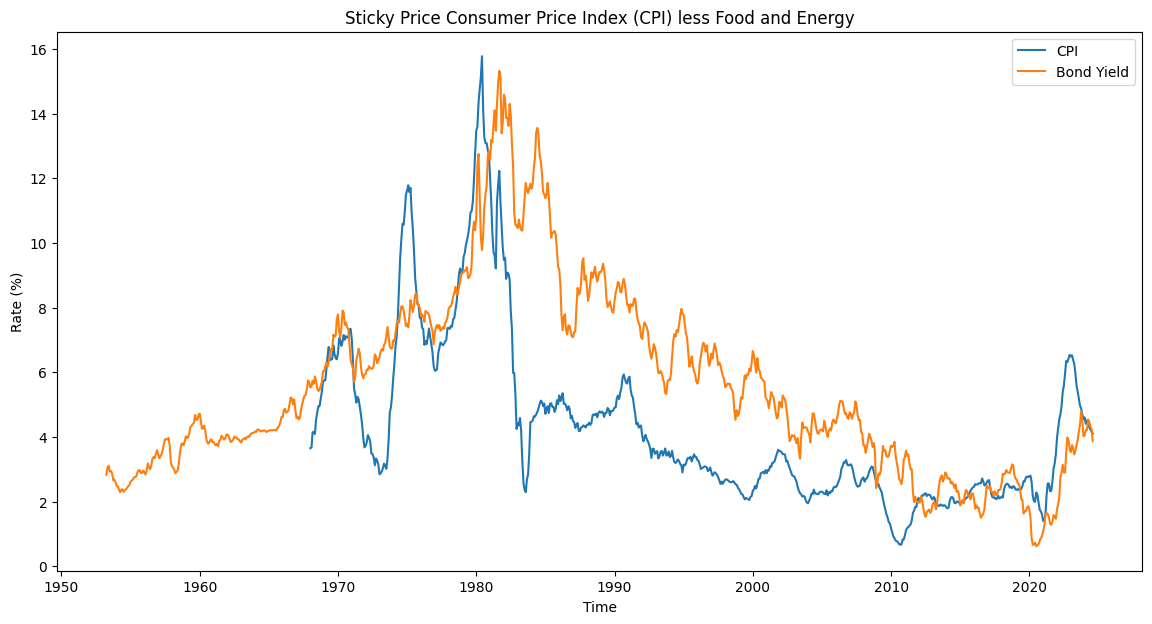

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(cpi.index, cpi.values, label="CPI")
ax.plot(bond_rate.index, bond_rate.values, label="Bond Yield")
ax.set_xlabel('Time')
ax.set_ylabel('Rate (%)')
ax.set_title('Sticky Price Consumer Price Index (CPI) less Food and Energy')
ax.legend()


> As expected, the US government bond yields change with central bank interest rates, which is adjusted frequently as a primary tool to manage inflation

#Scenario 6: Options for AAPL far in/out of the money


> Let's see if Apple far ITM/OTM options are illiquid, and how VIX affect their liquidity

In [ ]:
vix = yf.download("^VIX", period="1y", interval="1d")
aapl = yf.download('aapl', period="1y", interval="1d")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
aapl['ret'] = aapl['Adj Close'].pct_change() * 100
vix['ret'] = vix['Adj Close'].pct_change() * 100

In [ ]:
calls_aapl = options.get_calls("aapl")
calls_aapl.tail(20)

/usr/local/lib/python3.10/dist-packages/yahoo_fin/options.py:42: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(requests.get(site, headers=headers).text)


,Contract Name,Last Trade Date (EDT),Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility
28,AAPL241011C00232500,10/7/2024 6:38 PM,232.5,0.18,0.18,0.20,-0.43,-70.49%,8809,8473,24.85%
29,AAPL241011C00235000,10/7/2024 6:38 PM,235.0,0.08,0.07,0.08,-0.20,-71.43%,13995,16684,24.71%
30,AAPL241011C00237500,10/7/2024 6:38 PM,237.5,0.04,0.03,0.04,-0.07,-70.00%,3701,7205,25.78%
31,AAPL241011C00240000,10/7/2024 6:37 PM,240.0,0.02,0.01,0.02,-0.03,-60.00%,4945,8082,26.76%
32,AAPL241011C00242500,10/7/2024 6:35 PM,242.5,0.02,0.01,0.02,-0.01,-50.00%,1553,4420,30.08%
33,AAPL241011C00245000,10/7/2024 6:28 PM,245.0,0.02,0.00,0.02,0.00,0.00%,1119,11034,33.20%
34,AAPL241011C00247500,10/7/2024 6:35 PM,247.5,0.01,0.00,0.01,-0.01,-50.00%,295,1175,33.59%
35,AAPL241011C00250000,10/7/2024 6:07 PM,250.0,0.01,0.00,0.01,0.00,0.00%,35,3196,36.72%
36,AAPL241011C00252500,10/7/2024 2:55 PM,252.5,0.01,0.00,0.01,0.00,0.00%,1,246,39.06%
37,AAPL241011C00255000,10/7/2024 3:10 PM,255.0,0.01,0.00,0.01,0.00,0.00%,100,1256,42.19%


In [ ]:
# let's consider only deep ITM/OTM options with strike difference from AAPL price of at least 10%
cur_price = yf.download('aapl',period='1y', interval='1d').tail(1)['Close'].to_numpy()[0]
calls_aapl = calls_aapl[(calls_aapl["Strike"] > cur_price * 1.1) | (calls_aapl["Strike"] < cur_price * 0.9)]

[*********************100%***********************]  1 of 1 completed


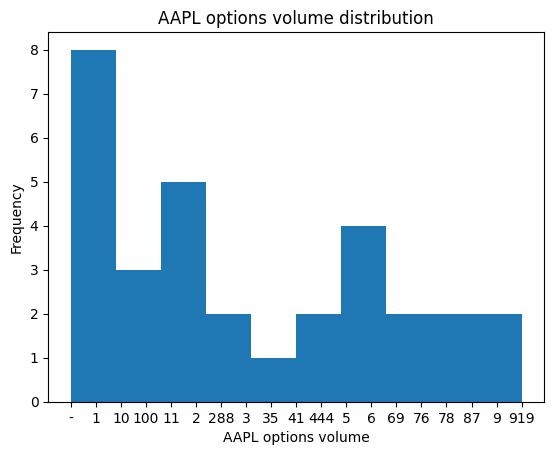

In [ ]:
a=calls_aapl['Volume'].sort_values()
plt.hist(a)
plt.xlabel('AAPL options volume')
plt.ylabel('Frequency')
plt.title('AAPL options volume distribution')
plt.show()



> It can be seen that deep ITM/OTM options is very illiquid



In [ ]:
# We will sum up volume of all deep ITM/OTM options
calls_option = calls_aapl["Contract Name"]
aapl_combine_calls = pd.Series(0, index=aapl.index)
for option in calls_option:
  try:
    _call = yf.download(option, period="max", interval="1d")
    _call = pd.Series(0, index=aapl.index) + _call["Volume"]
    _call.fillna(0, inplace=True)
    aapl_combine_calls += _call
  except:
    pass

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AAPL241011C00135000']: YFInvalidPeriodError("%ticker%: Period 'max' is invalid, must be one of ['1d', '5d']")
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********

Text(0.5, 1.0, 'Illiquid options and VIX')

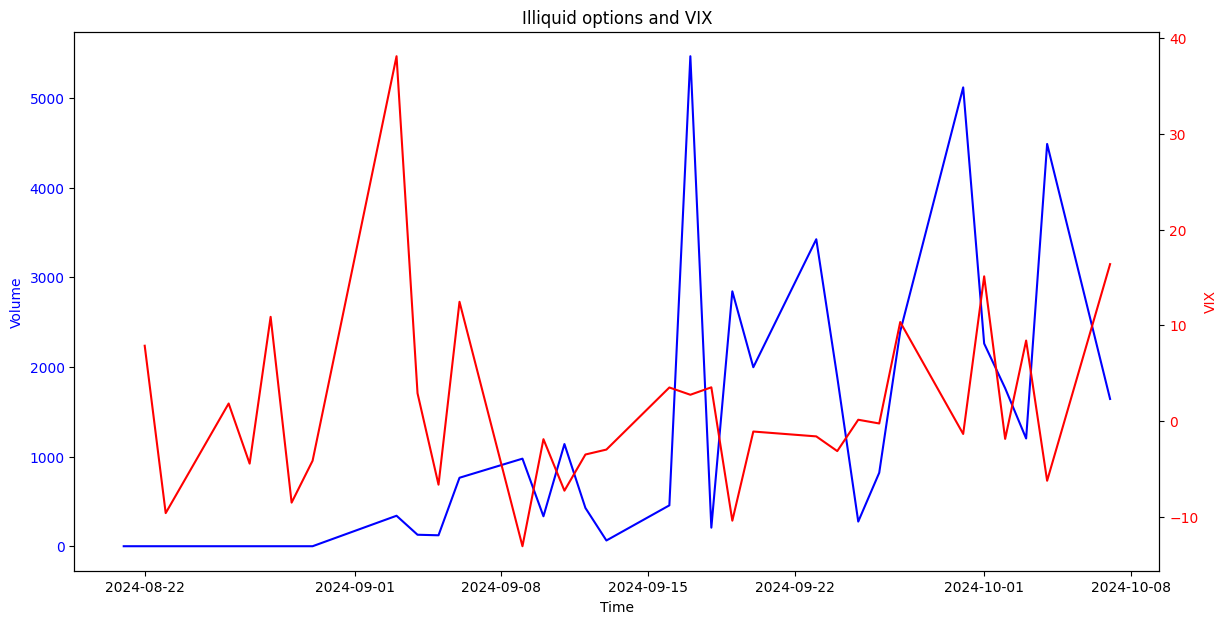

In [ ]:
# Let's plot options volume with VIX
fig, ax1 = plt.subplots()
fig.set_size_inches(14, 7)

ax1.plot(aapl_combine_calls.index, aapl_combine_calls.values, color='b', label='AAPL Option Volume')
ax1.set_xlabel('Time')
ax1.set_ylabel('Volume', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(vix.index, vix["ret"], color='r', label='VIX')
ax2.set_ylabel('VIX', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax1.set_title('Illiquid options and VIX')


> It can be observerd that VIX is a good indicator of the illiquidity of Apple call options: When VIX increases, the asset becomes illiquid, and vice versa. The data is still limited with less than 1 month of data of only call options of one underlying asset. We need to thoroughly study other illiquid asset in a longer span of time to make a conclusion.

## References

Board of Governors of the Federal Reserve System (US), Commercial Bank Interest

1. Rate on Credit Card Plans, All Accounts [TERMCBCCALLNS], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/TERMCBCCALLNS, September 26, 2024.
2. Board of Governors of the Federal Reserve System (US), Federal Funds Effective Rate [FEDFUNDS], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/FEDFUNDS, September 26, 2024.
3. Freddie Mac, 15-Year Fixed Rate Mortgage Average in the United States [MORTGAGE15US], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/MORTGAGE15US, September 26, 2024.
4. Board of Governors of the Federal Reserve System (US), Delinquency Rate on Single-Family Residential Mortgages, Booked in Domestic Offices, All Commercial Banks [DRSFRMACBS], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DRSFRMACBS, September 26, 2024.
5. Board of Governors of the Federal Reserve System (US), Delinquency Rate on Business Loans, All Commercial Banks [DRBLACBS], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DRBLACBS, September 26, 2024.
6. Organization for Economic Co-operation and Development, Interest Rates: Long-Term Government Bond Yields: 10-Year: Main (Including Benchmark) for United States [IRLTLT01USM156N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IRLTLT01USM156N, September 26, 2024.
7. Federal Reserve Bank of Atlanta, Sticky Price Consumer Price Index less Food and Energy [CORESTICKM159SFRBATL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CORESTICKM159SFRBATL, September 26, 2024.
8. Yahoo Finance, CBOE Volatility Index, https://finance.yahoo.com/quote/%5EVIX/, September 26, 2024.
9. Yahoo Finance, SPDR S&P 500 ETF Trust, https://finance.yahoo.com/quote/SPY/, September 26, 2024.
10. Yahoo Finance, Apple Inc., https://finance.yahoo.com/quote/AAPL/, September 26, 2024.
11. Yahoo Finance, Apple Options maturity Sep 27, https://finance.yahoo.com/quote/AAPL/options/?date=1727395200, September 26, 2024